download the dataset from kaggle

In [264]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mragpavank/insurance1")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\mragpavank\insurance1\versions\1


Import Libraries

In [265]:
import os 
import pandas as pd
import numpy as np 
from sklearn.preprocessing import StandardScaler , LabelEncoder
import torch 
from torch.utils.data import TensorDataset , DataLoader
from torch.optim import AdamW 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split

In [266]:
data = pd.read_csv(os.path.join(path , "insurance.csv"))

data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [267]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [268]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [269]:
print(data.shape)
data = data.dropna()
data = data.drop_duplicates()
print(data.shape)

(1338, 7)
(1337, 7)


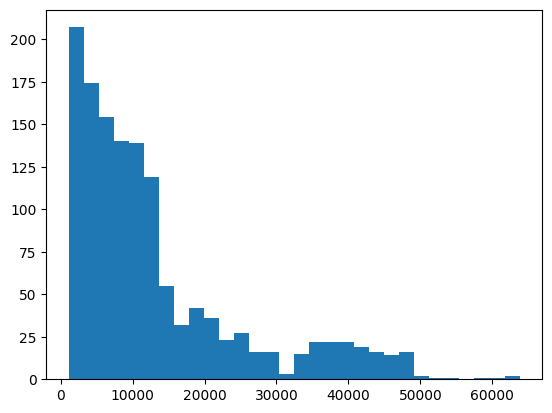

In [270]:
plt.hist(data["charges"], bins=30)
plt.show()

In [271]:
print(data["charges"].skew())

1.5153909108403483


In [272]:
data["charges"] = np.log1p(data["charges"])

print(data["charges"].skew())

-0.08955835073325419


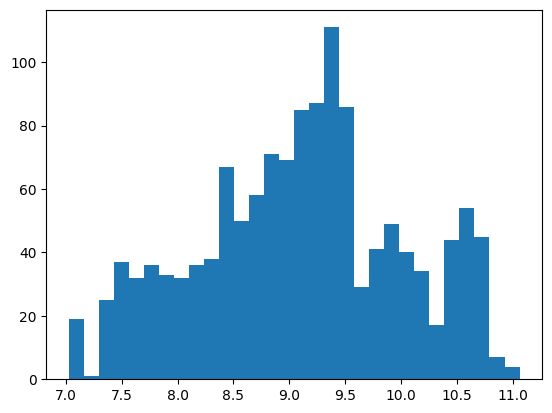

In [273]:
plt.hist(data["charges"] , bins=30)
plt.show()

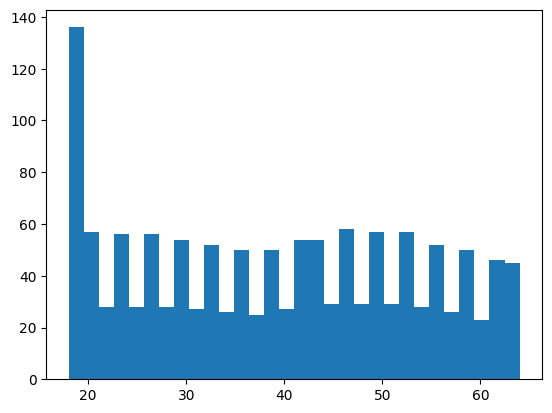

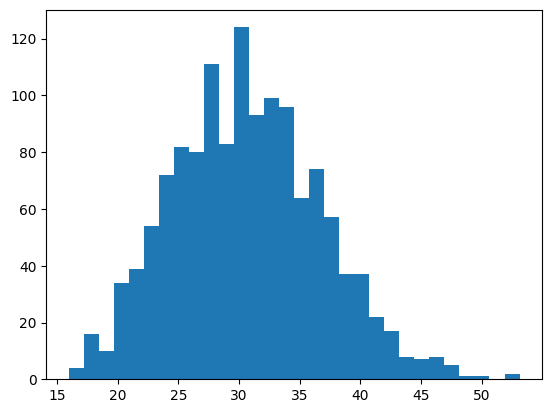

In [274]:

for column in ["age","bmi"]:
    plt.hist(data[column] , bins=30)
    plt.show()

In [275]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [276]:
data["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [277]:
cat_columns = ["sex" , "smoker" , "region"]

encoder = LabelEncoder()

for column in cat_columns:
    data[column] = encoder.fit_transform(data[column])

In [278]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,9.734236
1,18,1,33.770,1,0,2,7.453882
2,28,1,33.000,3,0,2,8.400763
3,33,1,22.705,0,0,1,9.998137
4,32,1,28.880,0,0,1,8.260455


In [279]:
X = data.drop("charges" , axis=1)
y = data["charges"]

In [280]:
x_train_val , x_test , y_train_val , y_test = train_test_split(X , y , test_size=0.1 , random_state=42)

In [281]:
x_train , x_val , y_train , y_val = train_test_split(x_train_val , y_train_val , test_size=0.1111 , random_state=42)

In [282]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_val =  scaler.transform(x_val)
x_test = scaler.transform(x_test)

y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(y_train.to_numpy().reshape(-1,1))
y_val = y_scaler.transform(y_val.to_numpy().reshape(-1,1))
y_test = y_scaler.transform(y_test.to_numpy().reshape(-1,1))

In [283]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(1069, 1)
(134, 1)
(134, 1)


In [284]:
x_train_tensor = torch.tensor(x_train , dtype=torch.float32)
x_val_tensor = torch.tensor(x_val , dtype=torch.float32)
x_test_tensor = torch.tensor(x_test , dtype=torch.float32)

y_train_tensor = torch.tensor(y_train , dtype=torch.float32)
y_val_tensor = torch.tensor(y_val , dtype=torch.float32)
y_test_tensor = torch.tensor(y_test , dtype=torch.float32)

In [285]:
train_dataset = TensorDataset(x_train_tensor , y_train_tensor)
val_dataset = TensorDataset(x_val_tensor , y_val_tensor)
test_dataset = TensorDataset(x_test_tensor , y_test_tensor)

In [286]:
train_loader = DataLoader(train_dataset , batch_size=32 , shuffle=True)
val_loader = DataLoader(val_dataset , batch_size=32 )
test_loader = DataLoader(test_dataset , batch_size=32)

In [287]:
for x_batch , y_batch in val_loader:
    print(x_batch.shape)
    print(y_batch.shape)
    break
    

torch.Size([32, 6])
torch.Size([32, 1])


In [288]:
input_dim = x_train.shape[1]
output_dim = 1 

In [289]:
import torch.nn as nn
class predict_charge(nn.Module):
    def __init__(self , input_dim , output_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim , 32), 
            nn.ReLU(),
            nn.Linear(32 , 64), 
            nn.ReLU(),
            nn.Linear(64 , 32) ,
            nn.ReLU(),
            nn.Linear(32 ,output_dim)
        )

    def forward(self, x):
        return self.network(x)

In [290]:
def initial_weights(x):
    if isinstance(x , nn.Linear):
        nn.init.kaiming_normal_(x.weight , nonlinearity="relu")
        nn.init.zeros_(x.bias)
    

In [291]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
print(device)

model = predict_charge(input_dim , output_dim)
model.apply(initial_weights)
loss_fn = nn.MSELoss()
optimizer = AdamW(model.parameters() , lr = 1e-4 , weight_decay=1e-3)

cuda


In [292]:
epochs = 50
patience = 10

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch
        y_batch = y_batch

        y_pred = model(X_batch)

        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch
            y_batch = y_batch

            y_pred = model(X_batch)

            loss = loss_fn(y_pred, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
        
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_regression_model.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

Epoch [1/50] Train Loss: 1.4472 Val Loss: 1.1276
Epoch [2/50] Train Loss: 1.0349 Val Loss: 0.7869
Epoch [3/50] Train Loss: 0.7770 Val Loss: 0.5816
Epoch [4/50] Train Loss: 0.6157 Val Loss: 0.4574
Epoch [5/50] Train Loss: 0.5190 Val Loss: 0.3858
Epoch [6/50] Train Loss: 0.4511 Val Loss: 0.3347
Epoch [7/50] Train Loss: 0.4003 Val Loss: 0.2999
Epoch [8/50] Train Loss: 0.3606 Val Loss: 0.2741
Epoch [9/50] Train Loss: 0.3290 Val Loss: 0.2540
Epoch [10/50] Train Loss: 0.3129 Val Loss: 0.2397
Epoch [11/50] Train Loss: 0.2901 Val Loss: 0.2285
Epoch [12/50] Train Loss: 0.2706 Val Loss: 0.2195
Epoch [13/50] Train Loss: 0.2588 Val Loss: 0.2144
Epoch [14/50] Train Loss: 0.2531 Val Loss: 0.2087
Epoch [15/50] Train Loss: 0.2363 Val Loss: 0.2042
Epoch [16/50] Train Loss: 0.2303 Val Loss: 0.2002
Epoch [17/50] Train Loss: 0.2261 Val Loss: 0.1968
Epoch [18/50] Train Loss: 0.2158 Val Loss: 0.1948
Epoch [19/50] Train Loss: 0.2174 Val Loss: 0.1921
Epoch [20/50] Train Loss: 0.2121 Val Loss: 0.1904
Epoch [21

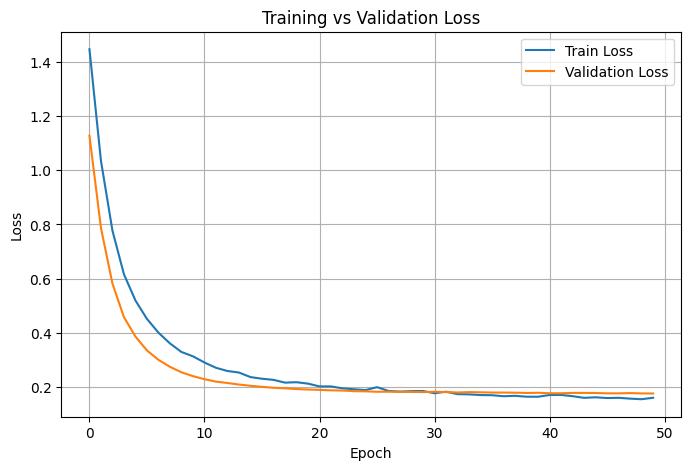

In [293]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [294]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



predictions = []
actuals = []

model.load_state_dict(torch.load("best_regression_model.pth"))
model.eval()

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch

        y_pred = model(X_batch)

        predictions.append(y_pred.cpu().numpy())
        actuals.append(y_batch.cpu().numpy())

predictions = np.vstack(predictions)
actuals = np.vstack(actuals)

predictions_original = y_scaler.inverse_transform(predictions)
actuals_original = y_scaler.inverse_transform(actuals)

predictions_original = np.expm1(predictions_original)
actuals_original = np.expm1(actuals_original)

mae = mean_absolute_error(actuals_original, predictions_original)
rmse = np.sqrt(mean_squared_error(actuals_original, predictions_original))
r2 = r2_score(actuals_original, predictions_original)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

MAE: 2676.22
RMSE: 4962.93
R2 Score: 0.8628
